In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Intrinsic generators: uniformity and correlation (qualitative tests)

a)

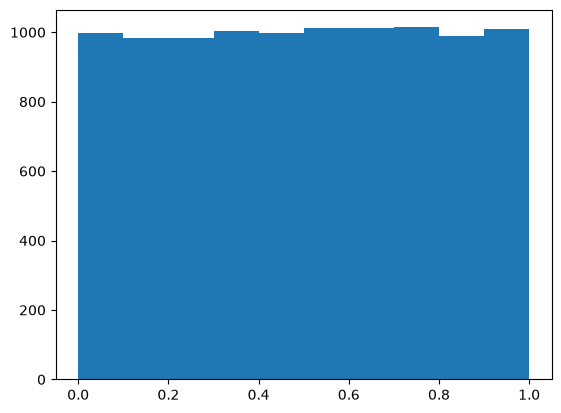

In [2]:
values = np.random.rand(10000)

plt.hist(values, bins=10)
plt.show()

b)

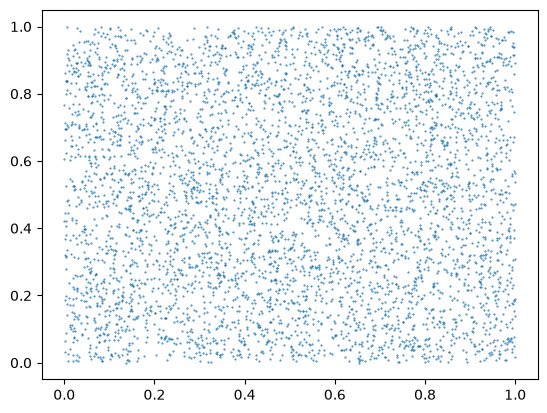

In [3]:
values = np.random.rand(10000)
x = values[0::2]
y = values[1::2]

plt.scatter(x, y, s=0.2)
plt.show()

## Intrinsic generators: uniformity and correlation (quantitative tests)

a)

In [4]:
def moment_order_k(x, k):

    return np.mean(x**k)

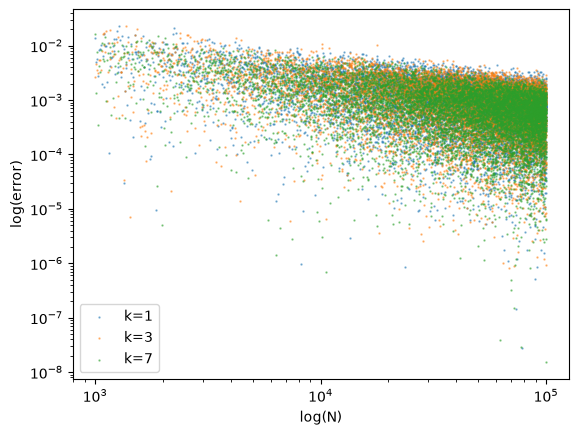

In [5]:
N = np.linspace(1000, 100000, 10000, dtype=int)
k = [1,3,7]
for j in k:
    
    errors = []
    
    for i in N:
    
        values = np.random.rand(i)
        xk_exact = 1/(j+1)
        error = abs(moment_order_k(values, j) - xk_exact)
        errors.append(error)

    errors = np.array(errors)
    
    plt.scatter(N,errors, label=f"k={j}", s=0.5, alpha=0.5)
    plt.ylabel('log(error)')
    plt.xlabel('log(N)')
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
plt.show()

b)

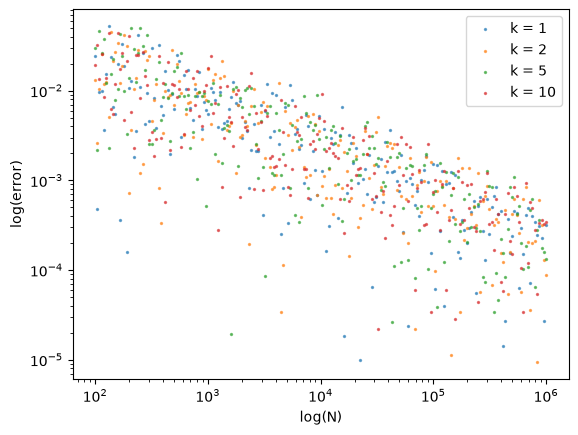

In [6]:
N = np.logspace(2, 6, 200, dtype=int)
k_list = [1, 2, 5, 10]

for k in k_list:
    errors = []
    for n in N:
        v = np.random.rand(n + k)
        errors.append(abs(np.mean(v[:-k] * v[k:]) - 0.25))
    
    plt.scatter(N, errors, s=2, label=f'k = {k}', alpha=0.6)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.legend()
plt.show()
    

## Exponential distribution with Inverse Transformation Method

a)

In [7]:
x = np.random.rand(1000)
z = - np.log(x)

b)

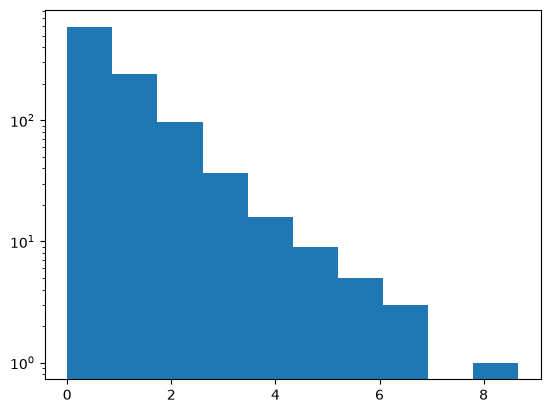

In [8]:
plt.hist(z, bins=10)
plt.yscale('log')
plt.show()

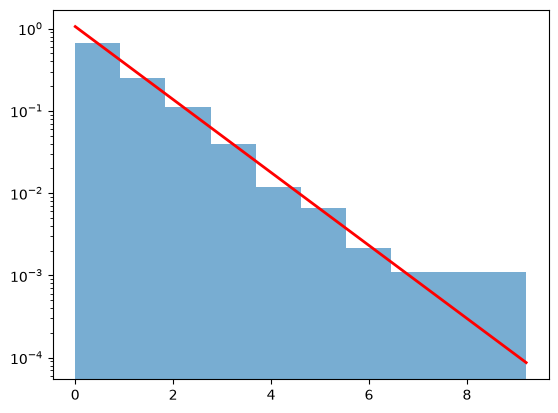

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.random.rand(1000)
z = -np.log(x)

counts, bin_edges = np.histogram(z, bins=10, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def exp_func(z, a, b):
    return a * np.exp(-b * z)

popt, pcov = curve_fit(exp_func, bin_centers, counts)

plt.hist(z, bins=10, density=True, alpha=0.6)

z_fit = np.linspace(min(z), max(z), 100)
plt.plot(z_fit, exp_func(z_fit, *popt), 'r-', lw=2, )

plt.yscale('log')
plt.show()

## An example of non uniform distribution: comparison between different algorithms

a)

In [10]:
x = np.random.rand(1000)
z = np.cos(np.pi*x)

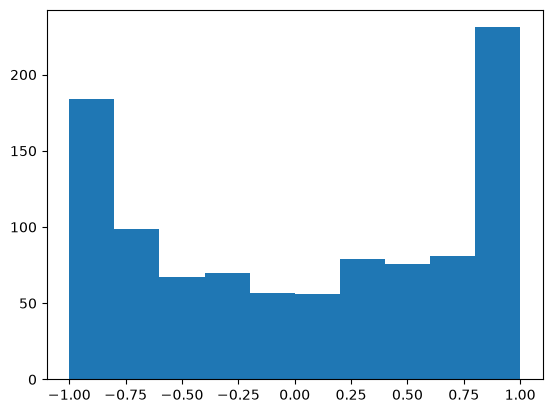

In [11]:
plt.hist(z, bins=10)
plt.show()

In [12]:
x = []
i = 0
while i < 1000:
    
    U = np.random.rand(1)
    V = np.random.rand(1)

    if U**2 + V**2 <=1:

        temp = (U**2 - V**2)/(U**2 + V**2)
        x.append(temp)
        i +=1
        
x = np.array(x) 

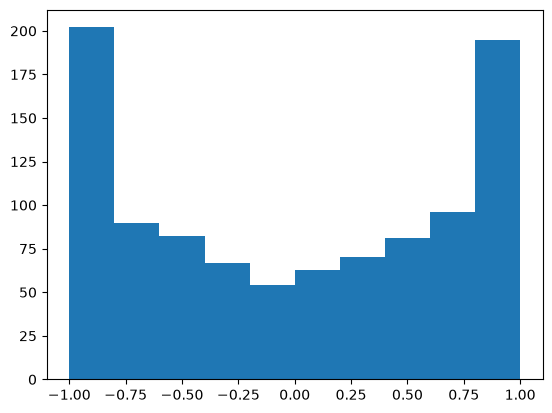

In [13]:
plt.hist(x, bins=10)
plt.show()

## Gaussian distribution: Box-Muller algorithm

In [14]:
U1 = np.random.uniform(size = 1000)
U2 = np.random.uniform(size = 1000)
R = np.sqrt(-2 * np.log(U1))
Theta = 2 * np.pi * U2
X = R * np.cos(Theta)

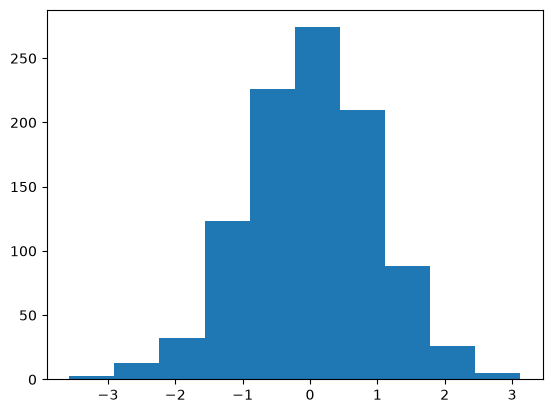

In [15]:
plt.hist(X, bins=10)
plt.show()

In [16]:
mean = np.mean(X)
variance = np.var(X)
print(f"media:{mean}, varianza:{variance}")

media:-0.008436237186328546, varianza:0.921413383620162


## Gaussian distribution: the central limit theorem

a)

In [17]:
media = []
N = 50

for i in range(1000):

    x = np.random.rand(N)*2 - 1
    media.append(np.mean(x))

media = np.array(media)
    

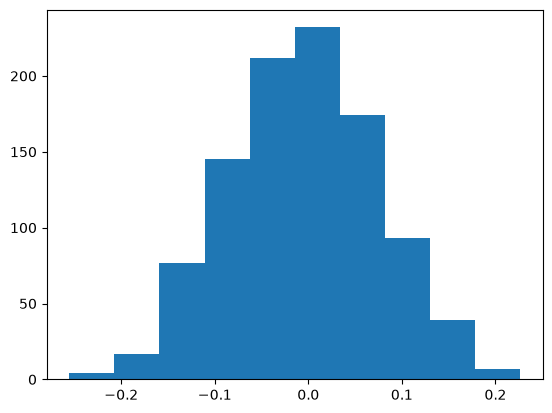

media:-0.005547307866791785, varianza:0.006354862612849706
media:-0.013210835290251579, varianza:0.006484478398520233


In [18]:
plt.hist(media, bins=10)
plt.show()

mean = np.mean(media)
var = np.var(media)

N = 1000
x = np.random.rand(N)*2 - 1

mean_analitico = np.mean(x)
var_analitico = (np.mean(x**2) - np.mean(x)**2)/50

print(f"media:{mean}, varianza:{var}")
print(f"media:{mean_analitico}, varianza:{var_analitico}")

In [19]:
np.mean(x**2)

np.float64(0.32439844609507784)

In [20]:
z = (media - mean)/var

In [21]:
media_quarta = np.mean(z**4)
media_seconda = 3*np.mean(z**2)**2 

print(media_quarta)
print(media_seconda)

67650.8402334793
74286.33337152717


d)

In [22]:
media = []
N = 50

for i in range(1000):

    x = np.random.exponential(size=N)
    media.append(np.mean(x))

media = np.array(media)

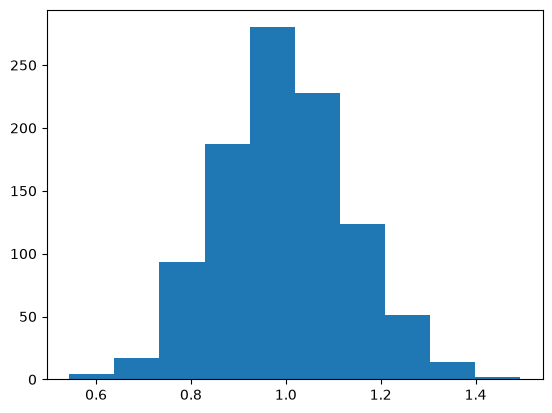

media:0.9961459400379039, varianza:0.018793805194435124
media:0.9403638762849487, varianza:0.015629019353673515


In [23]:
plt.hist(media, bins=10)
plt.show()

mean = np.mean(media)
var = np.var(media)

N = 1000
x = np.random.exponential(size=N)

mean_analitico = np.mean(x)
var_analitico = (np.mean(x**2) - np.mean(x)**2)/50

print(f"media:{mean}, varianza:{var}")
print(f"media:{mean_analitico}, varianza:{var_analitico}")

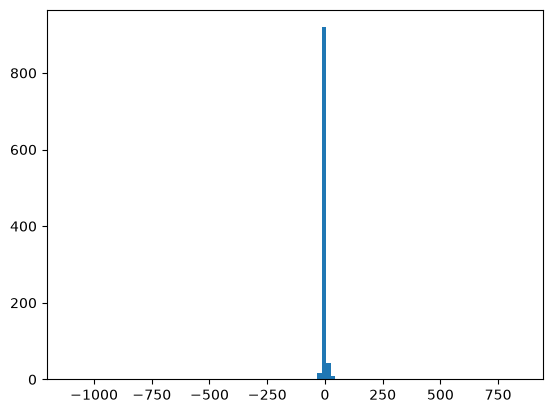

In [26]:
x = np.random.rand(1000)
r = np.tan(np.pi*(x - 0.5))

plt.hist(r, bins=100)
plt.show()